# C O Burning

In [1]:
from pynucastro.rates.aprox_family_rates import make_CO_approximation

In [2]:
import pynucastro as pyna

In [3]:
rl = pyna.ReacLibLibrary()

## C+O burning network

In [4]:
net = pyna.network_helper(["p", "he4", "c12", "o16",
                           "ne20", "mg24", "si28",
                           "s32", "na23", "al27", "p31"])

In [5]:
r3a = net.get_rate_by_name("a(aa,g)C12")
r3a_reverse = net.get_rate_by_name("c12(g,aa)a")

net.remove_rates([r3a, r3a_reverse])

In [6]:
rcne = net.get_rate_by_name("ne20(c12,p)p31")
rcne2 = net.get_rate_by_name("ne20(c12,a)si28")
rcne_reverse = net.get_rate_by_name("p31(p,c12)ne20")
rcne2_reverse = net.get_rate_by_name("si28(a,c12)ne20")

net.remove_rates([rcne, rcne2, rcne_reverse, rcne2_reverse])

In [7]:
net.rates

[C12 + He4 ⟶ O16 + 𝛾,
 O16 + He4 ⟶ Ne20 + 𝛾,
 Ne20 + He4 ⟶ Mg24 + 𝛾,
 Na23 + p ⟶ Mg24 + 𝛾,
 Na23 + He4 ⟶ Al27 + 𝛾,
 Mg24 + He4 ⟶ Si28 + 𝛾,
 Al27 + p ⟶ Si28 + 𝛾,
 Al27 + He4 ⟶ P31 + 𝛾,
 Si28 + He4 ⟶ S32 + 𝛾,
 P31 + p ⟶ S32 + 𝛾,
 C12 + C12 ⟶ p + Na23,
 C12 + C12 ⟶ He4 + Ne20,
 O16 + C12 ⟶ p + Al27,
 O16 + C12 ⟶ He4 + Mg24,
 O16 + O16 ⟶ p + P31,
 O16 + O16 ⟶ He4 + Si28,
 Na23 + p ⟶ He4 + Ne20,
 Al27 + p ⟶ He4 + Mg24,
 P31 + p ⟶ He4 + Si28,
 O16 ⟶ He4 + C12,
 Ne20 ⟶ He4 + O16,
 Mg24 ⟶ p + Na23,
 Mg24 ⟶ He4 + Ne20,
 Al27 ⟶ He4 + Na23,
 Si28 ⟶ p + Al27,
 Si28 ⟶ He4 + Mg24,
 P31 ⟶ He4 + Al27,
 S32 ⟶ p + P31,
 S32 ⟶ He4 + Si28,
 Ne20 + He4 ⟶ p + Na23,
 Ne20 + He4 ⟶ C12 + C12,
 Na23 + p ⟶ C12 + C12,
 Mg24 + He4 ⟶ p + Al27,
 Mg24 + He4 ⟶ C12 + O16,
 Al27 + p ⟶ C12 + O16,
 Si28 + He4 ⟶ p + P31,
 Si28 + He4 ⟶ O16 + O16,
 P31 + p ⟶ O16 + O16]

In [8]:
rnaal = net.get_rate_by_name("na23(a,g)al27")
rnaal_reverse = net.get_rate_by_name("al27(g,a)na23")
ralp = net.get_rate_by_name("al27(a,g)p31")
ralp_reverse = net.get_rate_by_name("p31(g,a)al27")

net.remove_rates([rnaal, rnaal_reverse, ralp, ralp_reverse])

In [9]:
net.summary()

Network summary
---------------
  explicitly carried nuclei: 11
  approximated-out nuclei: 0
  inert nuclei (included in carried): 0

  total number of rates: 34

  rates explicitly connecting nuclei: 34
  hidden rates: 0

  reaclib rates: 17
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 0
  approximate rates: 0
  derived rates: 17
  modified rates: 0
  custom rates: 0


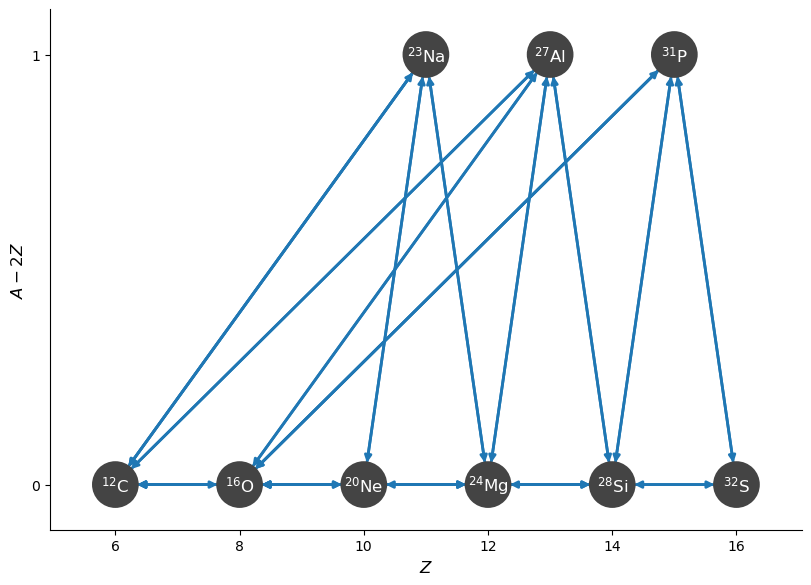

In [10]:
fig = net.plot(rotated=True)

In [11]:
net.write_network("full_net.py")

/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))


In [12]:
import full_net as fn

In [13]:
from scipy.integrate import solve_ivp
import numpy as np

In [14]:
rho = 1.e7
T = 3e9

X0 = np.zeros(fn.nnuc)
X0[fn.jc12] = 0.5
X0[fn.jo16] = 0.5

Y0 = X0 / fn.A

In [15]:
tmax = 100.0

sol = solve_ivp(fn.rhs, [0, tmax], Y0, method="BDF", jac=fn.jacobian,
                dense_output=True, args=(rho, T), rtol=1.e-6, atol=1.e-8)

In [16]:
import matplotlib.pyplot as plt

/home/zingale/development/pynucastro/pynucastro/networks/python_network.py:694: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


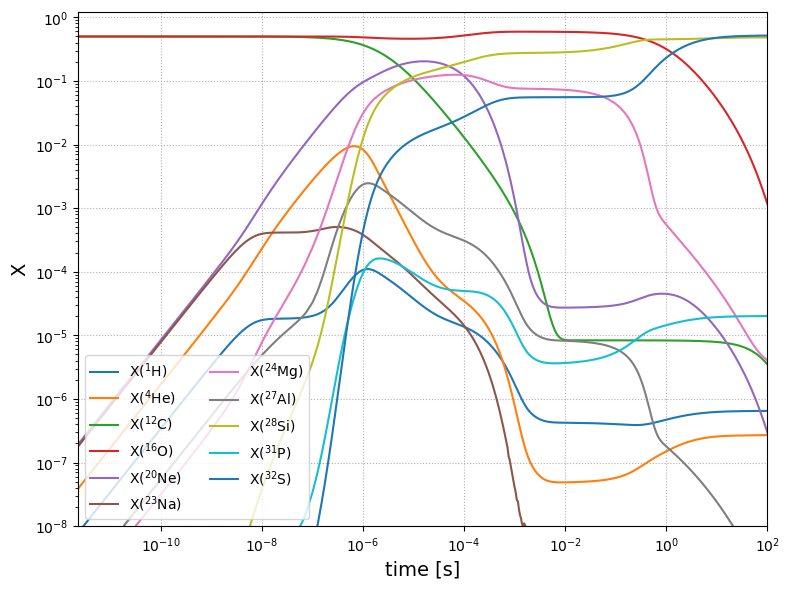

In [17]:
fig = net.plot_evolution(sol, ymin=1.e-8)

## An approximate network

In [18]:
crates = make_CO_approximation(rl.get_rates(), "C")

C12 C12 Ne20 Mg24 Na23


In [19]:
corates = make_CO_approximation(rl.get_rates(), "CO")

C12 O16 Mg24 Si28 Al27


In [20]:
orates = make_CO_approximation(rl.get_rates(), "O")

O16 O16 Si28 S32 P31


In [21]:
c12ag = rl.get_rate_by_name("c12(a,g)o16")
c12ag_reverse = rl.get_rate_by_name("o16(g,a)c12")

In [22]:
anet = pyna.PythonNetwork(rates=crates+corates+orates+[c12ag,c12ag_reverse])

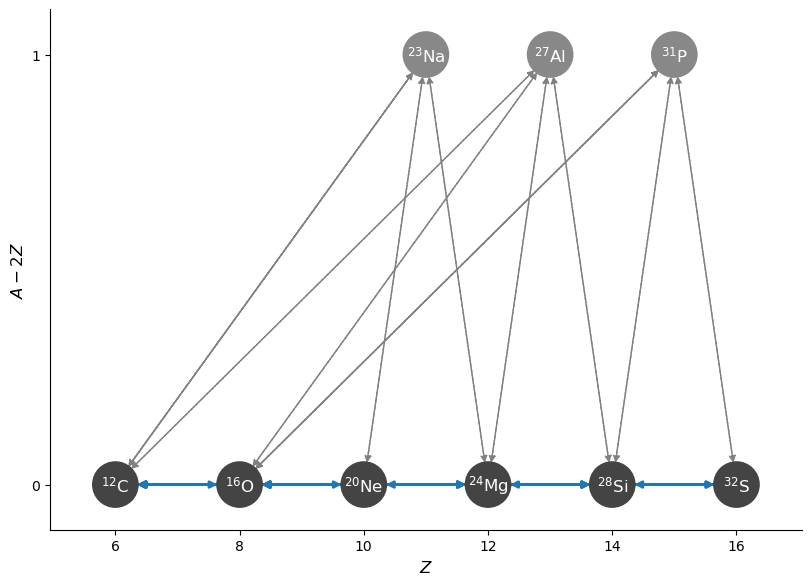

In [23]:
fig = anet.plot(rotated=True)

In [24]:
anet.summary()

Network summary
---------------
  explicitly carried nuclei: 7
  approximated-out nuclei: 3
  inert nuclei (included in carried): 0

  total number of rates: 50

  rates explicitly connecting nuclei: 20
  hidden rates: 30

  reaclib rates: 32
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 0
  approximate rates: 18
  derived rates: 0
  modified rates: 0
  custom rates: 0


In [25]:
anet.write_network("coapprox.py")

In [26]:
import coapprox as ap

In [27]:
rho = 1.e7
T = 3e9

X0 = np.zeros(ap.nnuc)
X0[ap.jc12] = 0.5
X0[ap.jo16] = 0.5

Y0 = X0 / ap.A

In [28]:
sol2 = solve_ivp(ap.rhs, [0, tmax], Y0, method="BDF", jac=ap.jacobian,
                dense_output=True, args=(rho, T), rtol=1.e-6, atol=1.e-8)

/home/zingale/development/pynucastro/pynucastro/networks/python_network.py:694: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


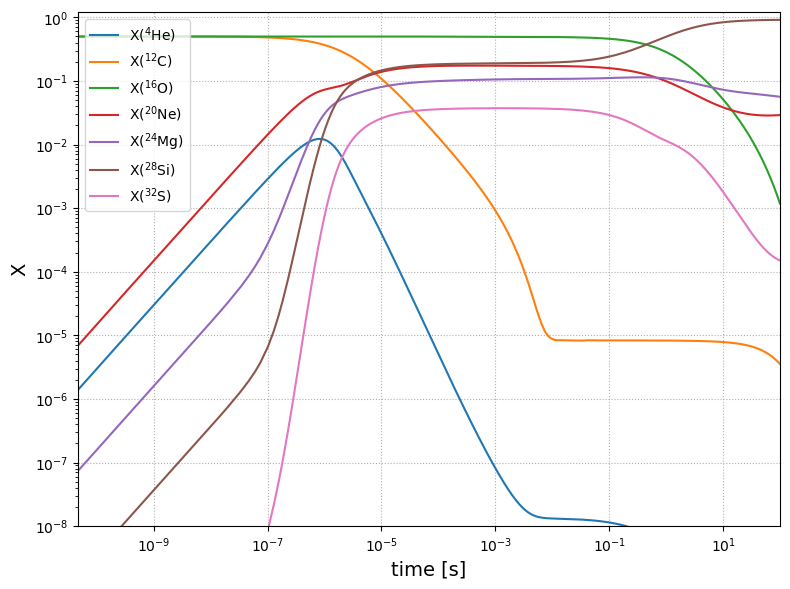

In [30]:
fig2 = anet.plot_evolution(sol2, ymin=1.e-8)

In [32]:
sol2

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.790e-10 ...  9.777e+01  1.000e+02]
        y: [[ 0.000e+00  1.341e-06 ...  1.035e-11  1.025e-11]
            [ 4.167e-02  4.166e-02 ...  3.015e-07  2.950e-07]
            ...
            [ 0.000e+00  2.341e-10 ...  3.261e-02  3.262e-02]
            [ 0.000e+00  2.003e-14 ...  4.725e-06  4.682e-06]]
      sol: <scipy.integrate._ivp.common.OdeSolution object at 0x7f3b6cc8b4d0>
 t_events: None
 y_events: None
     nfev: 901
     njev: 16
      nlu: 77